# Izaz Khan  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 11

***Date:*** 18/04/2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize

In [ ]:
df = pd.read_csv("imdb_top_1000.csv", engine='python')
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
sentences = df['Overview'].head(5).tolist()

for i, s in enumerate(sentences):
    print(f"Sentence {i+1}:")
    print(s[:200])   # first 200 characters
    print()

Sentence 1:
Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.

Sentence 2:
An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.

Sentence 3:
When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.

Sentence 4:
The early life and career of Vito Corleone in 1920s New York City is portrayed, while his son, Michael, expands and tightens his grip on the family crime syndicate.

Sentence 5:
A jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence.



In [ ]:
sentence = sentences[0]
print(sentence)

Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.


In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform([sentence]).toarray()
words = vectorizer.get_feature_names_out()

print("Words:", words)
print("Embedding Shape:", X.shape)

Words: ['acts' 'and' 'bond' 'common' 'decency' 'eventual' 'finding' 'imprisoned'
 'men' 'number' 'of' 'over' 'redemption' 'solace' 'through' 'two' 'years']
Embedding Shape: (1, 17)


In [ ]:
embedding_matrix = np.eye(len(words))

print("Embedding Matrix Shape:", embedding_matrix.shape)
embedding_matrix

Embedding Matrix Shape: (17, 17)


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0

In [ ]:
Q = embedding_matrix
K = embedding_matrix
V = embedding_matrix

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (17, 17)
K shape: (17, 17)
V shape: (17, 17)


In [ ]:
d_k = K.shape[1]

scores = np.dot(Q, K.T) / np.sqrt(d_k)

print("Attention Scores Shape:", scores.shape)
scores

Attention Scores Shape: (17, 17)


array([[0.24253563, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.24253563, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.24253563, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.24253563, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.      

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

attention_weights = softmax(scores)

print("Attention Weights Shape:", attention_weights.shape)
attention_weights

Attention Weights Shape: (17, 17)


array([[0.07377802, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.07377802, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.07377802, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.05788887, 0.07377802, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.05788887, 0.057888

In [ ]:
output = np.dot(attention_weights, V)

print("Output Shape:", output.shape)
output

Output Shape: (17, 17)


array([[0.07377802, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.07377802, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.07377802, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.05788887, 0.07377802, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887],
       [0.05788887, 0.05788887, 0.05788887, 0.057888

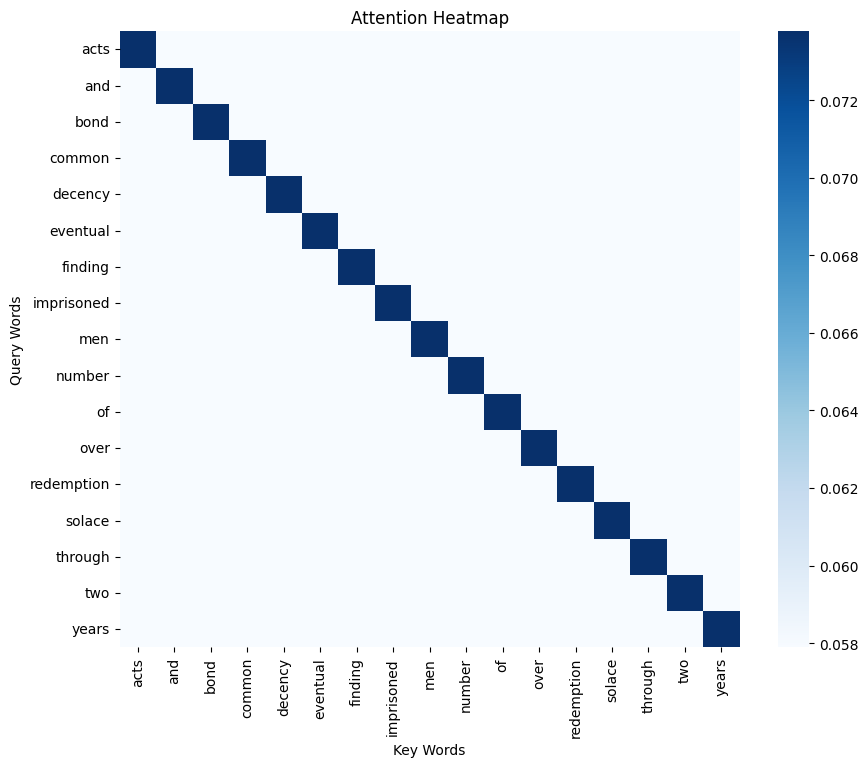

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(attention_weights, xticklabels=words, yticklabels=words, cmap='Blues')
plt.title("Attention Heatmap")
plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.show()

In [ ]:
for i, word in enumerate(words):
    max_idx = np.argmax(attention_weights[i])
    print(f"'{word}' attends most to '{words[max_idx]}' with score {attention_weights[i][max_idx]:.4f}")

'acts' attends most to 'acts' with score 0.0738
'and' attends most to 'and' with score 0.0738
'bond' attends most to 'bond' with score 0.0738
'common' attends most to 'common' with score 0.0738
'decency' attends most to 'decency' with score 0.0738
'eventual' attends most to 'eventual' with score 0.0738
'finding' attends most to 'finding' with score 0.0738
'imprisoned' attends most to 'imprisoned' with score 0.0738
'men' attends most to 'men' with score 0.0738
'number' attends most to 'number' with score 0.0738
'of' attends most to 'of' with score 0.0738
'over' attends most to 'over' with score 0.0738
'redemption' attends most to 'redemption' with score 0.0738
'solace' attends most to 'solace' with score 0.0738
'through' attends most to 'through' with score 0.0738
'two' attends most to 'two' with score 0.0738
'years' attends most to 'years' with score 0.0738


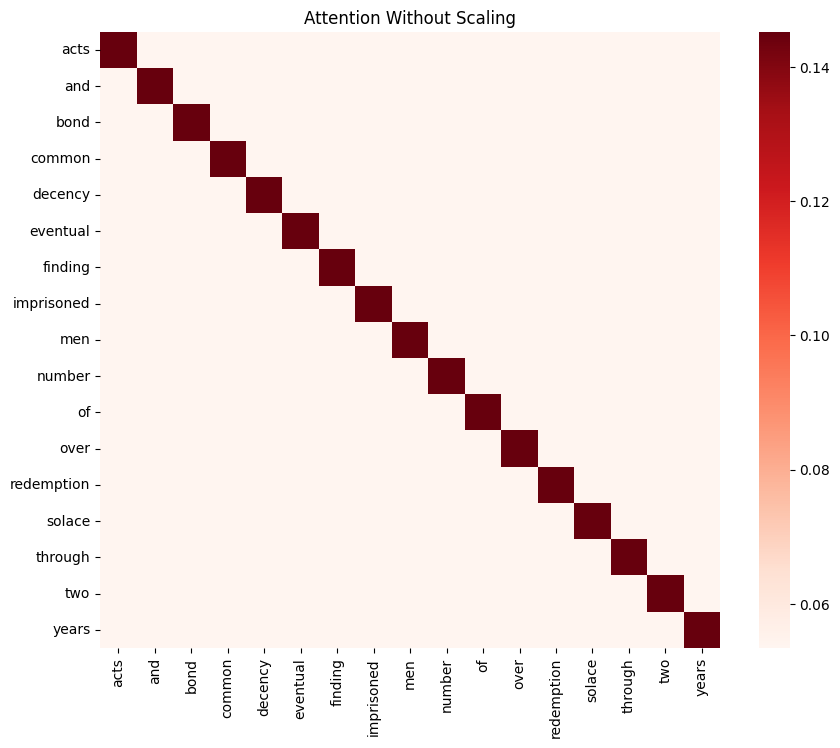

In [ ]:
scores_no_scaling = np.dot(Q, K.T)
attention_no_scaling = softmax(scores_no_scaling)

plt.figure(figsize=(10,8))
sns.heatmap(attention_no_scaling, xticklabels=words, yticklabels=words, cmap='Reds')
plt.title("Attention Without Scaling")
plt.show()

In [ ]:
output_no_softmax = np.dot(scores, V)

print("Output without softmax:")
output_no_softmax

Output without softmax:


array([[0.24253563, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.24253563, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.24253563, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.24253563, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.      

In [ ]:
query_word = words[0]
query_index = 0

Q_single = Q[query_index:query_index+1]

scores_single = np.dot(Q_single, K.T) / np.sqrt(d_k)
attention_single = softmax(scores_single)

print(f"Attention for query word: '{query_word}'")
attention_single

Attention for query word: 'acts'


array([[0.07377802, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887, 0.05788887, 0.05788887, 0.05788887,
        0.05788887, 0.05788887]])

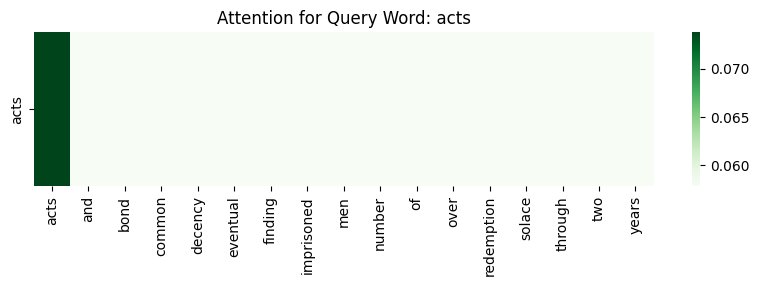

In [ ]:
plt.figure(figsize=(10,2))
sns.heatmap(attention_single, xticklabels=words, yticklabels=[query_word], cmap='Greens')
plt.title(f"Attention for Query Word: {query_word}")
plt.show()

In [ ]:
max_idx = np.argmax(attention_single)
print(f"The query word '{query_word}' attends most to '{words[max_idx]}'")

The query word 'acts' attends most to 'acts'


#**TASK 06 ANSWERS**



##1. Which words get highest attention?

**ANS:**

 Words mostly give highest attention to themselves. This happens because the query and key vectors are the same, so a word is most similar to itself.



##2. Does attention focus on meaningful words?

**ANS:**

  In this implementation, attention is not very meaningful because simple embeddings are used. In real models, attention focuses on important words like subjects and actions.


##3. What happens if scaling is removed?

**ANS:**

 Without scaling, the attention scores become very large. This makes softmax give very high weight to one word and very low to others, which makes the model unstable.


##4. What happens if softmax is removed?

**ANS:**

  Without softmax, the scores are not normalized and cannot be treated as probabilities. This leads to incorrect and unreliable attention outputs.

